In [46]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf

Download Monthly Historical Data


In [48]:
btc = yf.download('BTC-USD', start='2020-07-07', end='2025-07-07', interval='1mo')


C:\Users\farha\AppData\Local\Temp\ipykernel_15296\4044411983.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Save to CSV

In [49]:
btc.to_csv('btc_usd_monthly.csv')

PANDAS [DATA MANIPULATION & ANALYSIS]

In [50]:
df = pd.read_csv("btc_usd_monthly.csv")


In [51]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-08-01,11680.8203125,12359.056640625,11012.4150390625,11322.5703125,708377092130
3,2020-09-01,10784.4912109375,12067.0810546875,9916.4931640625,11679.31640625,1075949438431
4,2020-10-01,13780.9951171875,14028.2138671875,10416.689453125,10795.2548828125,1050874546086


In [52]:
df

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-08-01,11680.8203125,12359.056640625,11012.4150390625,11322.5703125,708377092130
3,2020-09-01,10784.4912109375,12067.0810546875,9916.4931640625,11679.31640625,1075949438431
4,2020-10-01,13780.9951171875,14028.2138671875,10416.689453125,10795.2548828125,1050874546086
...,...,...,...,...,...,...
57,2025-03-01,82548.9140625,95043.4375,76624.25,84373.8671875,1049435373908
58,2025-04-01,94207.3125,95768.390625,74436.6796875,82551.921875,1060974068310
59,2025-05-01,104638.09375,111970.171875,93399.859375,94212.859375,1496397538233
60,2025-06-01,107135.3359375,110561.421875,98286.203125,104637.296875,1424277758118


In [53]:
df.shape

(62, 6)

In [54]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [55]:
df.describe()

,Price,Close,High,Low,Open,Volume
count,62,61,61,61,61,61
unique,62,61,61,61,61,61
top,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
freq,1,1,1,1,1,1


In [56]:
df.info

<bound method DataFrame.info of          Price             Close              High               Low  \
0       Ticker           BTC-USD           BTC-USD           BTC-USD   
1         Date               NaN               NaN               NaN   
2   2020-08-01     11680.8203125   12359.056640625  11012.4150390625   
3   2020-09-01  10784.4912109375  12067.0810546875   9916.4931640625   
4   2020-10-01  13780.9951171875  14028.2138671875   10416.689453125   
..         ...               ...               ...               ...   
57  2025-03-01     82548.9140625        95043.4375          76624.25   
58  2025-04-01        94207.3125      95768.390625     74436.6796875   
59  2025-05-01      104638.09375     111970.171875      93399.859375   
60  2025-06-01    107135.3359375     110561.421875      98286.203125   
61  2025-07-01    108034.3359375    110541.4609375    105157.3984375   

                Open         Volume  
0            BTC-USD        BTC-USD  
1                NaN       

In [57]:
missing_values = df.isnull().sum()
print(missing_values)

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


No Numeric missing values found in this dataset

MATPLOTLIB (DATA PLOTTING)

In [58]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-08-01,11680.8203125,12359.056640625,11012.4150390625,11322.5703125,708377092130
3,2020-09-01,10784.4912109375,12067.0810546875,9916.4931640625,11679.31640625,1075949438431
4,2020-10-01,13780.9951171875,14028.2138671875,10416.689453125,10795.2548828125,1050874546086


LINE GRAPH

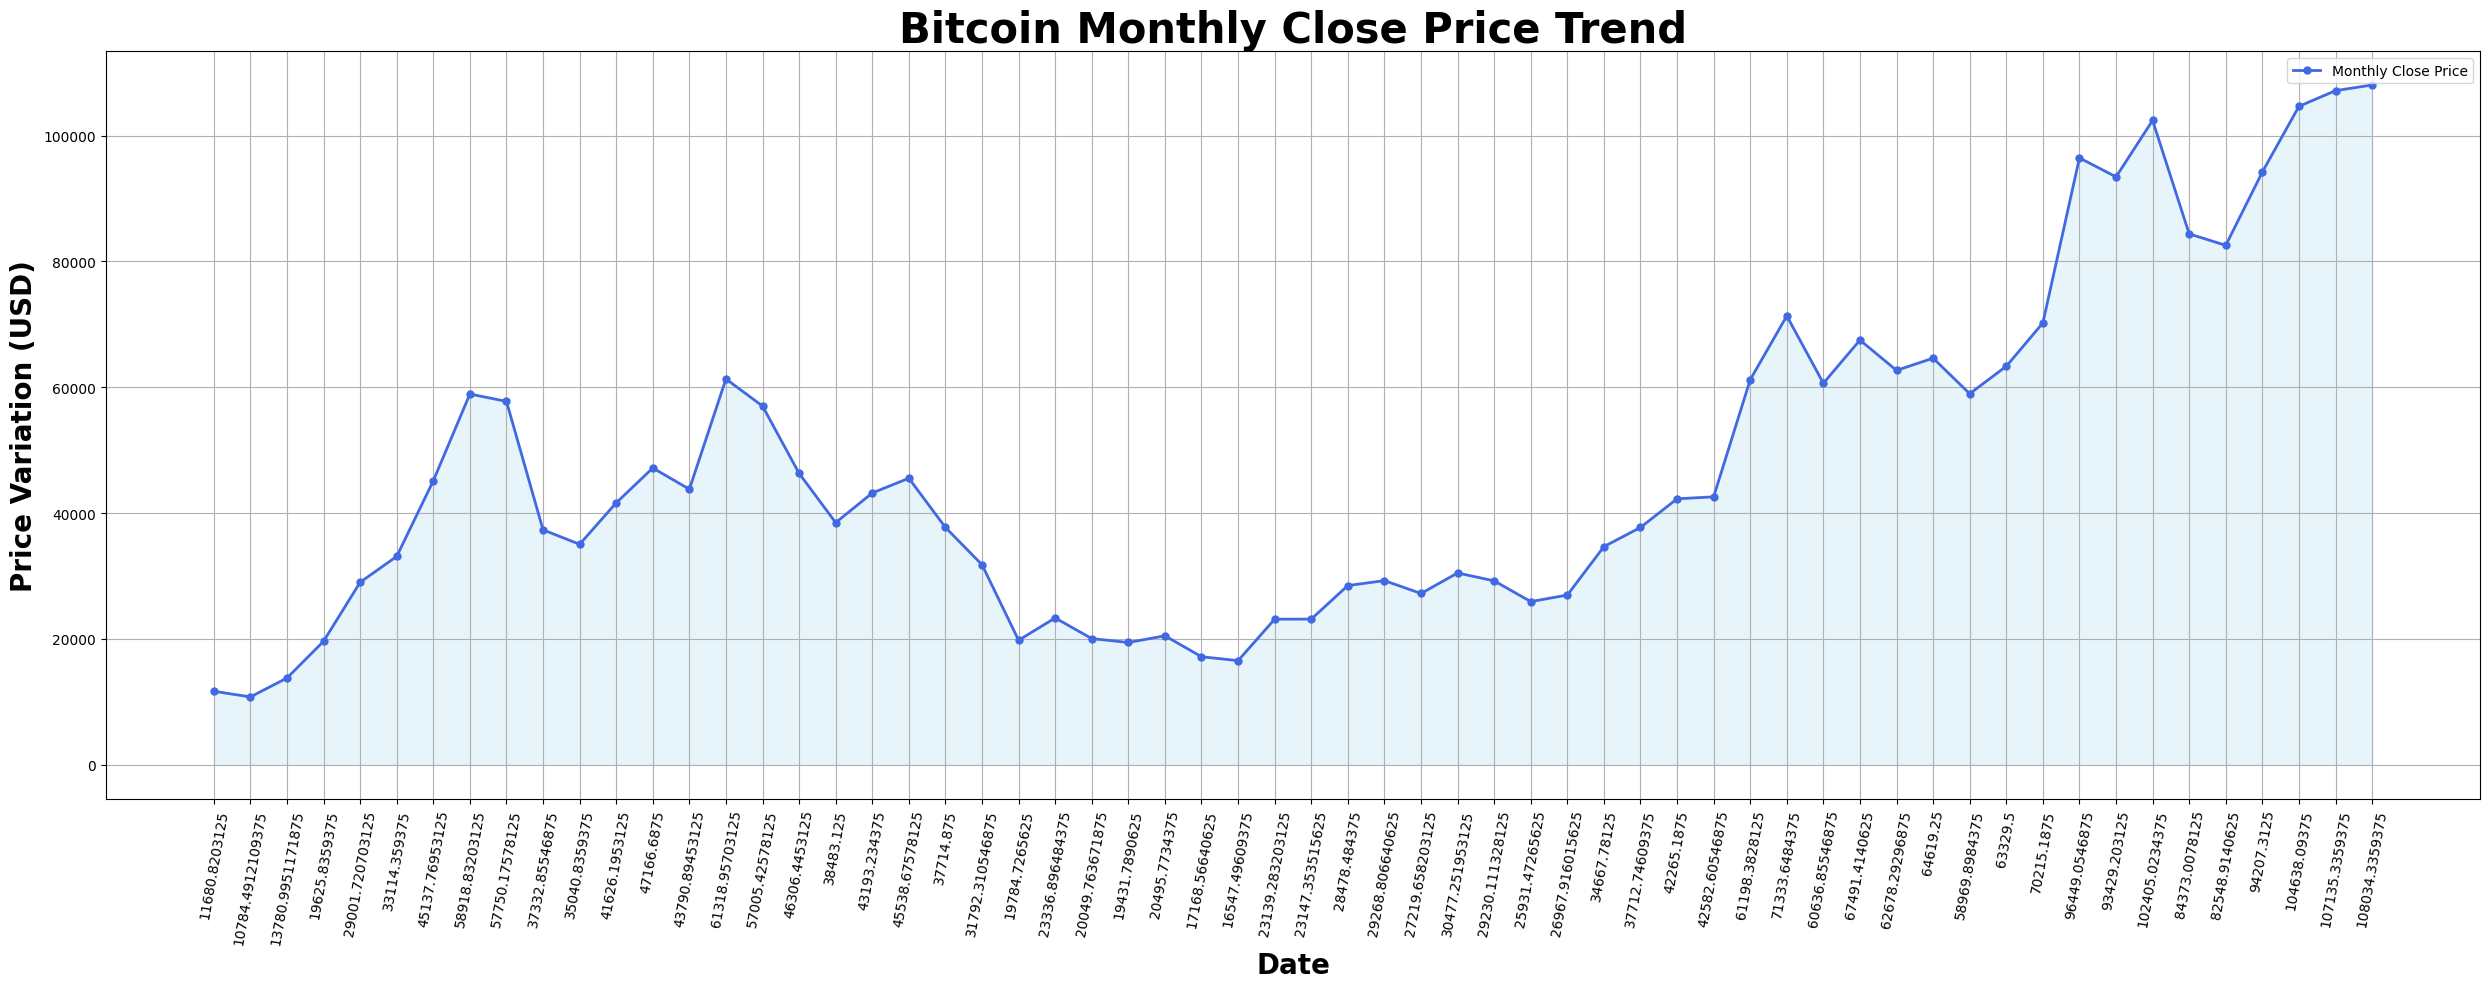

In [75]:
plt.figure(figsize=(25, 10))

plt.plot(df['Price'], df['Close'], label='Monthly Close Price',
         color='royalblue', linewidth=2, marker='o', markersize=5)
plt.fill_between(df['Price'], df['Close'], color='skyblue', alpha=0.2)

plt.title("Bitcoin Monthly Close Price Trend", fontsize=30, weight='bold')
plt.xlabel("Date", fontsize=20, weight='bold')
plt.ylabel("Price Variation (USD)", fontsize=20, weight='bold')
plt.xticks(rotation=80)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


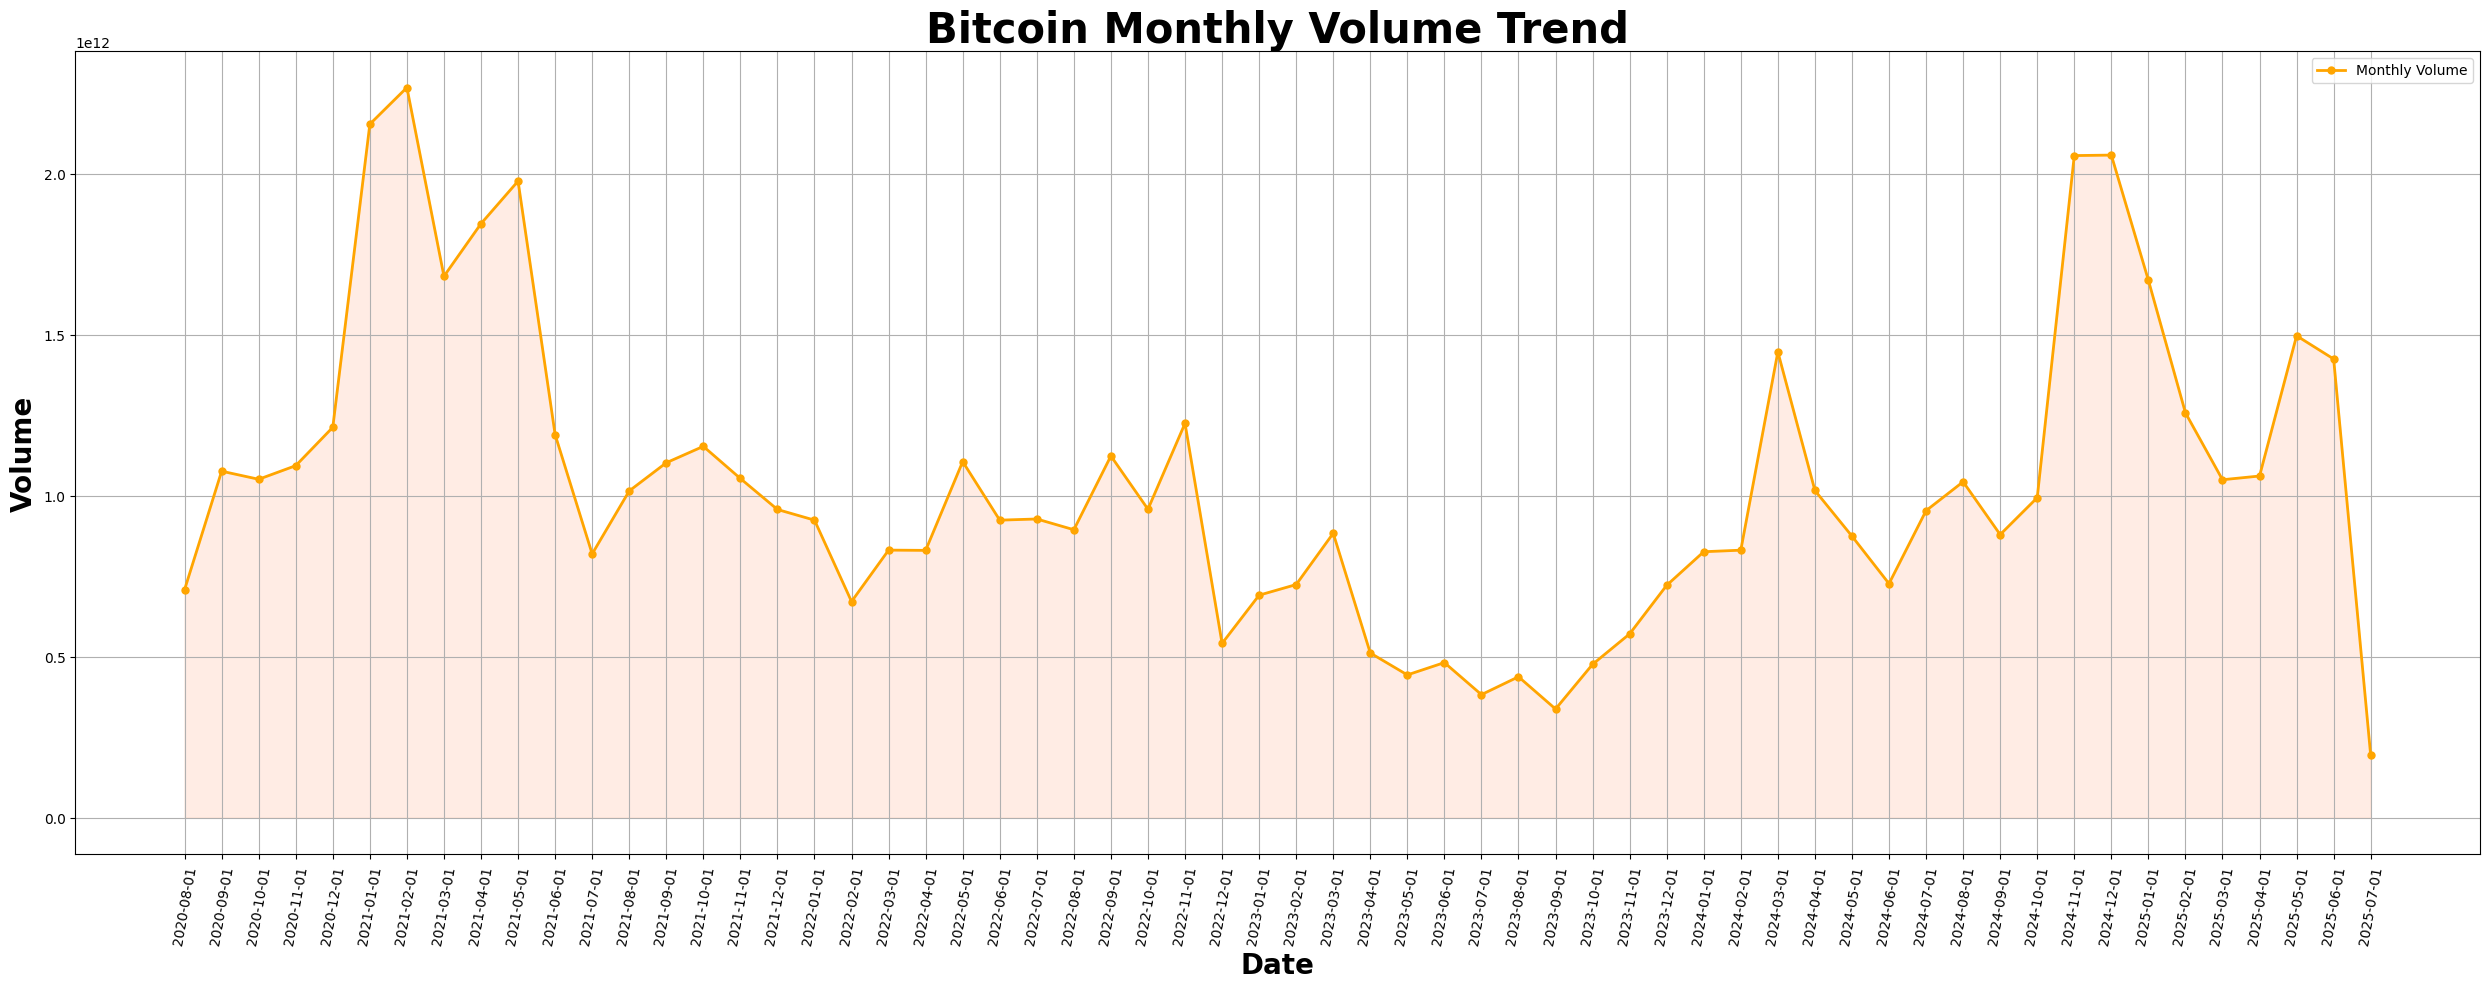

In [77]:
plt.figure(figsize=(25, 10))
plt.plot(df['Date'], df['Volume'], label='Monthly Volume',

         color='orange', linewidth=2, marker='o', markersize=5)
plt.fill_between(df['Date'], df['Volume'], color='lightsalmon', alpha=0.2)
plt.title("Bitcoin Monthly Volume Trend", fontsize=30, weight='bold')
plt.xlabel("Date", fontsize=20, weight='bold')
plt.ylabel("Volume", fontsize=20, weight='bold')
plt.xticks(rotation=80)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

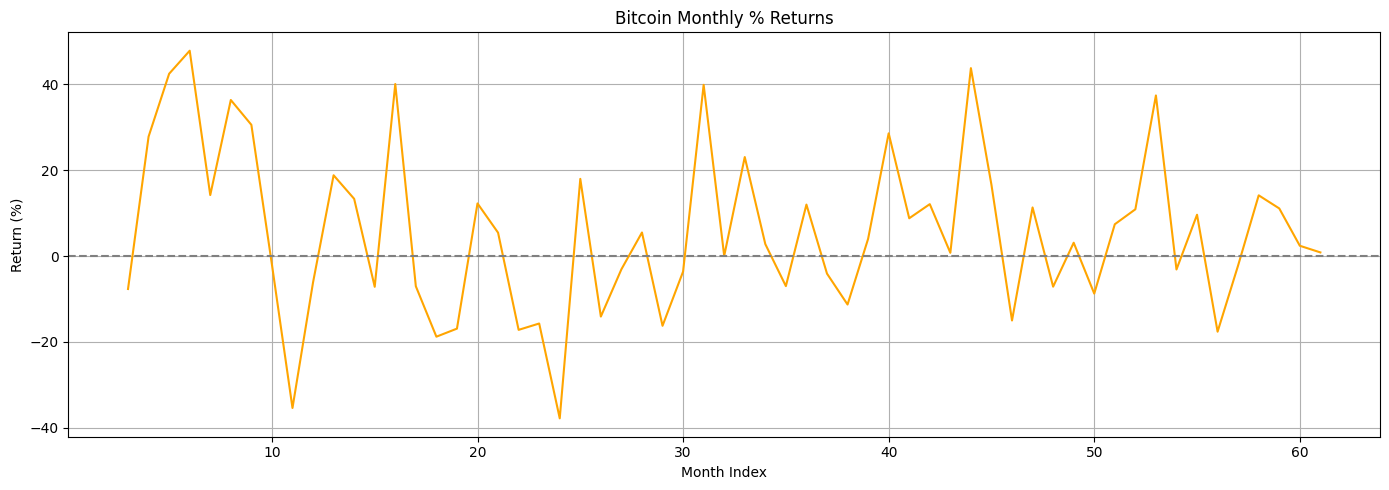

In [ ]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
# Calculate monthly percentage return
df['Monthly Return %'] = df['Close'].pct_change() * 100
# Drop rows with NaN (if any)
df.dropna(subset=['Monthly Return %'], inplace=True)

plt.figure(figsize=(14, 5))
sns.lineplot(x=df.index, y='Monthly Return %', data=df, color='orange')
plt.axhline(0, linestyle='--', color='gray')
plt.title("Bitcoin Monthly % Returns")
plt.ylabel("Return (%)")
plt.xlabel("Month Index")
plt.grid(True)
plt.tight_layout()
plt.show()


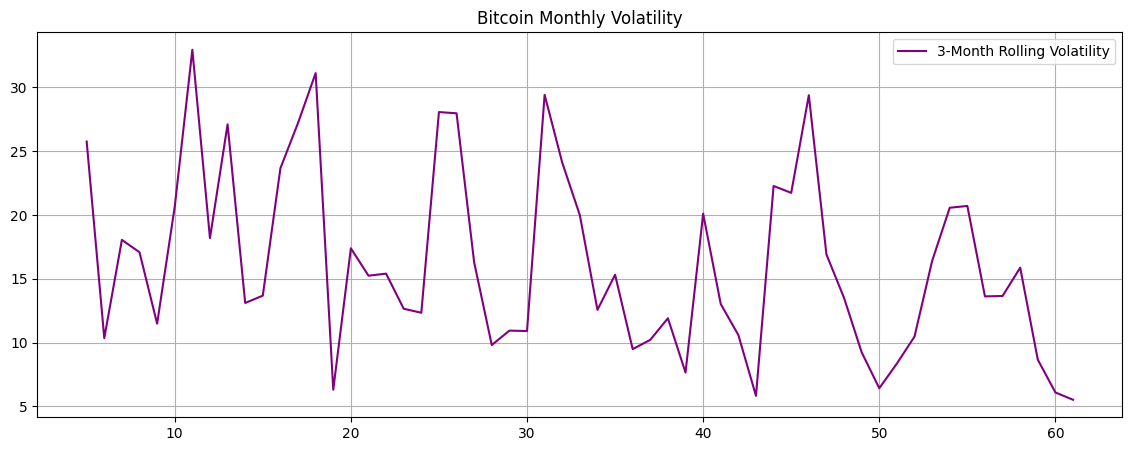

In [ ]:
df['Volatility'] = df['Monthly Return %'].rolling(window=3).std()

plt.figure(figsize=(14, 5))
plt.plot(df['Volatility'], color='purple', label='3-Month Rolling Volatility')
plt.title("Bitcoin Monthly Volatility")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_month = df.loc[df['Monthly Return %'].idxmax()]
worst_month = df.loc[df['Monthly Return %'].idxmin()]

# Print results with formatting
print(f"Best Month:")
print(f"Closing Price: ${best_month['Close']:,.2f}")
print(f"Monthly Return: {best_month['Monthly Return %']:.2f}%\n")

print(f"Worst Month:")
print(f"Closing Price: ${worst_month['Close']:,.2f}")
print(f"Monthly Return: {worst_month['Monthly Return %']:.2f}%")

Best Month:
Closing Price: $29,001.72
Monthly Return: 47.77%

Worst Month:
Closing Price: $19,784.73
Monthly Return: -37.77%


LINEAR REGRESSION


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("btc_usd_monthly.csv")
df.head()


,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-08-01,11680.8203125,12359.056640625,11012.4150390625,11322.5703125,708377092130
3,2020-09-01,10784.4912109375,12067.0810546875,9916.4931640625,11679.31640625,1075949438431
4,2020-10-01,13780.9951171875,14028.2138671875,10416.689453125,10795.2548828125,1050874546086


In [ ]:
df = pd.read_csv("btc_usd_monthly.csv", header=0, index_col=0)
df = df.drop('Ticker')
df = df.dropna()
df['Close'] = pd.to_numeric(df['Close'])

In [ ]:
X = df.drop('Close', axis=1)
y = df['Close']

Train Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)


Model

In [61]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Prediction

In [62]:
y_pred = model.predict(X_test)

In [63]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 19148003.73587479
MAE: 3700.7346745901646
R²: 0.9280581186188158


MSE--> Closer to 0 is better 
(The squared error is quite large because price values are in thousands not a problem on its own, but shows big deviations in some predictions.)

MAE--> Closer to 0 is better
(On average, your model's predictions are off by $3,700, which is substantial given Bitcoin's price range)

R² --> 1 = perfect, 0 = bad, negative = worse than baseline
(Your model explains 92.8% of the variance very strong for a simple linear model)

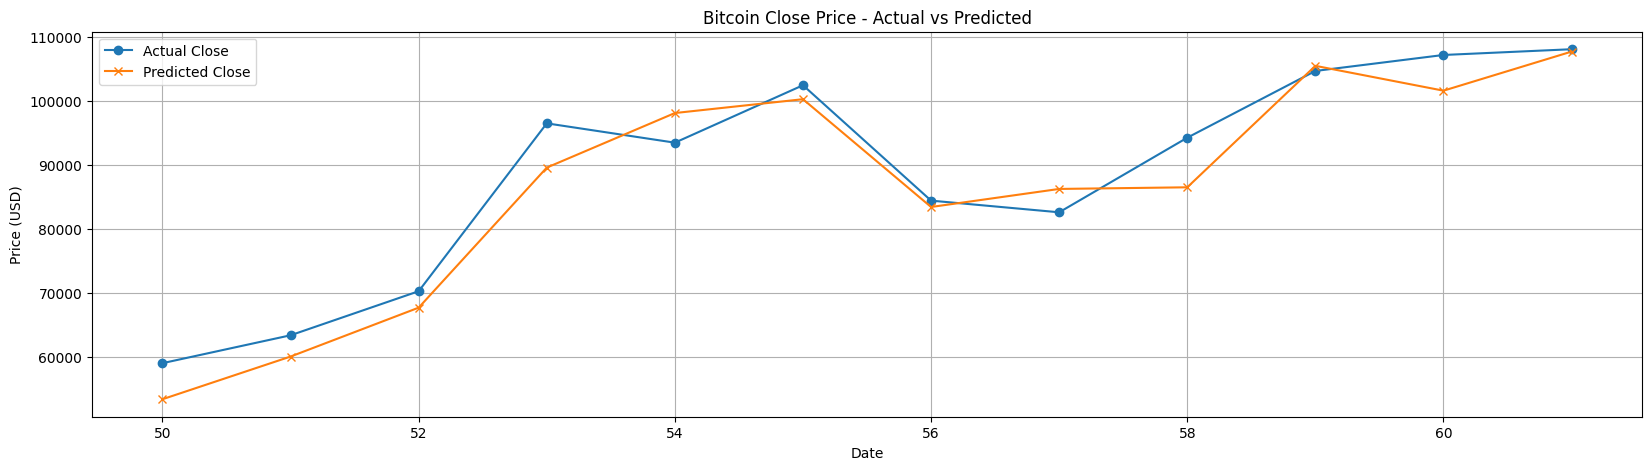

In [64]:
plt.figure(figsize=(20,5))
plt.plot(df.index[-len(y_test):], y_test, label='Actual Close', marker='o')
plt.plot(df.index[-len(y_test):], y_pred, label='Predicted Close', marker='x')
plt.title("Bitcoin Close Price - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [78]:
features = ['Open', 'High', 'Low', 'Volume']
X_multi = df[features]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, shuffle=False, test_size=0.2)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)

print("Multi-Feature R²:", r2_score(y_test, y_pred_multi))


Multi-Feature R²: 0.9280581186188158


RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
df = pd.read_csv('btc_usd_monthly.csv', header=None)
df = df.iloc[2:] 

In [67]:
df.columns = ['Date', 'Price', 'Open', 'High', 'Low', 'Volume']

In [68]:
df = df.dropna()
df['Close'] = pd.to_numeric(df['Price'])
df['Open'] = pd.to_numeric(df['Open'])
df['High'] = pd.to_numeric(df['High'])
df['Low'] = pd.to_numeric(df['Low'])
df['Volume'] = pd.to_numeric(df['Volume'])

In [69]:
features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Close']


Train Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

Model

In [71]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [72]:
# Prediction
y_pred = rf.predict(X_test)

In [73]:
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: -1.9200433011500464
MAE: 23755.034746093752
MSE: 777196800.6102332


MAE -->	Very large average prediction error.
MSE	--> Extremely large squared error, indicating high volatility in prediction mistakes.

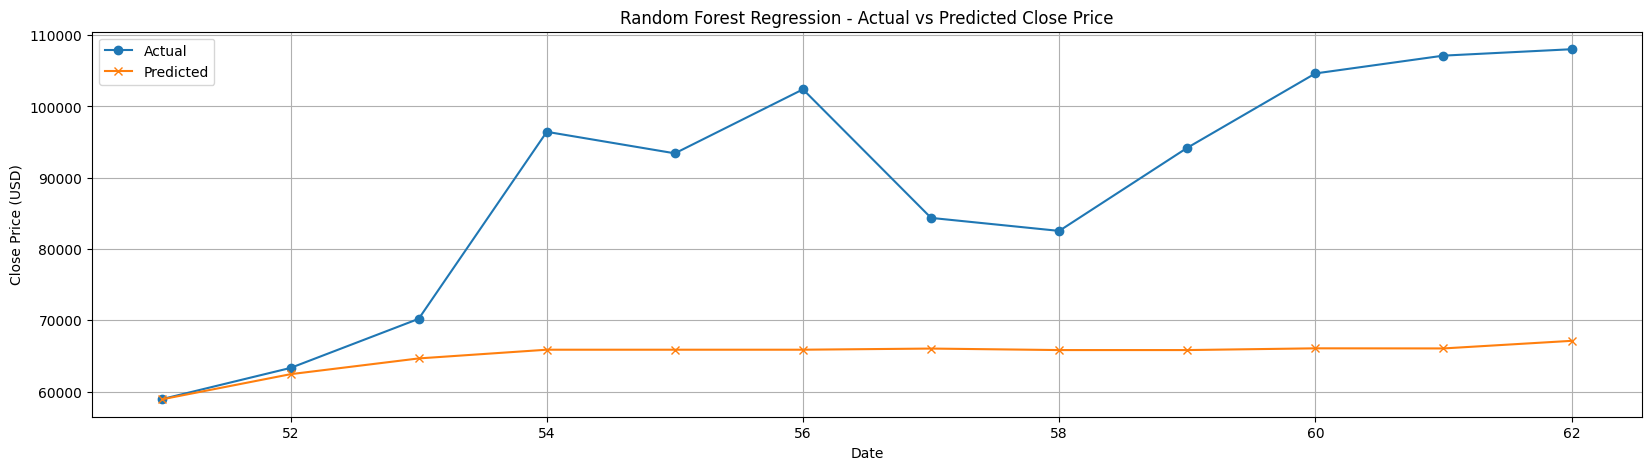

In [79]:
plt.figure(figsize=(20
                , 5))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted', marker='x')
plt.title('Random Forest Regression - Actual vs Predicted Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()
